# Configuração do Ambiente Virtual

Siga as instruções abaixo para configurar o ambiente deste notebook:

1. **Execute a célula de código abaixo.** Ela usará o `uv` para criar um ambiente virtual (`.venv`) e instalará as bibliotecas necessárias, incluindo o `ipykernel`.
2. **Execute um Reload Window** (Ctrl+Shift+P → Developer: Reload Window).
3. **Troque o Kernel do Notebook no VS Code:**
   * Após a execução concluir, clique no nome do Kernel atual, no **canto superior direito** da janela do notebook.
   * Escolha **"Select Another Kernel..."** (Selecionar Outro Kernel).
   * Selecione **"Jupyter"** .
   * Escolha o Python que está dentro da pasta `.venv` que acabou de ser criada (ex: `./.venv/bin/python`).
4. **Pronto!** Agora você pode executar as próximas células de análise de dados sem problemas de dependências.

In [1]:
# Instala o uv (caso não esteja instalado no ambiente base)
%pip install uv

# Cria o ambiente virtual (.venv) no diretório atual e força a substituição se já existir
!uv venv --clear # Voce pode desabilitar essa linha se ja tiver o .venv no projeto. 

# Instala as bibliotecas e o ipykernel para o VS Code reconhecer o ambiente
!uv pip install pandas numpy matplotlib scikit-learn imbalanced-learn



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Using CPython 3.13.9
Creating virtual environment at: .venv
Activate with: source .venv/bin/activate
Resolved 18 packages in 2.15s                                        
⠙ Preparing packages... (0/1)                                                   
⠙ Preparing packages... (0/1)-------------------     0 B/4.73 MiB            
⠙ Preparing packages... (0/1)------------------- 14.01 KiB/4.73 MiB          
⠙ Preparing packages... (0/1)------------------- 30.01 KiB/4.73 MiB          
⠙ Preparing packages... (0/1)------------------- 46.01 KiB/4.73 MiB          
⠙ Preparing packages... (0/1)------------------- 62.01 KiB/4.73 MiB          
⠙ Preparing packages... (0/1)------------------- 76.13 KiB/4.73 MiB          
⠙ Preparing packages... (0/1)------------------- 92.13 KiB/4.73 MiB          
⠙ Preparing packages...

In [2]:
!uv pip install ipykernel

Resolved 29 packages in 861ms                                        
Installed 26 packages in 1.23s                              
 + asttokens==3.0.1
 + comm==0.2.3
 + debugpy==1.8.20
 + decorator==5.2.1
 + executing==2.2.1
 + ipykernel==7.2.0
 + ipython==9.11.0
 + ipython-pygments-lexers==1.1.1
 + jedi==0.19.2
 + jupyter-client==8.8.0
 + jupyter-core==5.9.1
 + matplotlib-inline==0.2.1
 + nest-asyncio==1.6.0
 + parso==0.8.6
 + pexpect==4.9.0
 + platformdirs==4.9.4
 + prompt-toolkit==3.0.52
 + psutil==7.2.2
 + ptyprocess==0.7.0
 + pure-eval==0.2.3
 + pygments==2.19.2
 + pyzmq==27.1.0
 + stack-data==0.6.3
 + tornado==6.5.5
 + traitlets==5.14.3
 + wcwidth==0.6.0


In [3]:
!uv run python -m ipykernel install --user --name aula-02 --display-name "cursos-eng-dados-spaceship-titanic(uv)"



Installed kernelspec aula-02 in /home/saulo/.local/share/jupyter/kernels/aula-02


# Data Preparation Pipeline for Machine Learning
## Case Study: Spaceship Titanic Dataset (Kaggle)

> **Contexto:** O ano é 2912. A espaçonave *Titanic* colidiu com uma anomalia espaço-temporal. Metade dos passageiros foi teleportada para uma dimensão alternativa. Nossa missão é prever quem foi transportado (Target = `Transported`).

Etapas:
1. Análise dos Dados (EDA)
2. Limpeza de Dados (imputação de nulos + Feature Engineering em `Cabin`)
3. Tratamento de Outliers
4. Transformações Estatísticas (Log + StandardScaler)
5. Encoding de Variáveis Categóricas
6. Seleção de Features
7. Split do Dataset e Balanceamento


![imagem](..//aula-01-titanic/image/pipeline-pre-processamento.jpg)


A imagem divide o pipeline em duas macrofases (Fase 1: Exploração e Saneamento / Fase 2: Engenharia e Estruturação) e abriga os 7 passos descritos da seguinte forma:

Na **Fase 1: Exploração e Saneamento**:

*   A bolha amarela do topo (**EDA e Limpeza Inicial**): Contempla perfeitamente as etapas **1 (Análise dos Dados - EDA)** e **2 (Limpeza de Dados)**. O texto nela diz: "Compreensão visual dos dados seguida da correção de erros e valores ausentes".
*   A bolha verde-água inferior (**Tratamento de Outliers**): Reflete de forma direta a etapa **3 (Tratamento de Outliers)**.

Na **Fase 2: Engenharia e Estruturação**:

*   A engrenagem laranja superior (**Transformações e Encoding**): Agrupa logicamente as etapas **4 (Transformações Estatísticas)** e **5 (Encoding de Variáveis Categóricas)**.
*   A balança vermelha inferior (**Seleção e Split Final**): Sintetiza a etapa **6 (Seleção de Features)** ("Escolha de features relevantes") e engloba perfeitamente a etapa **7 (Split do Dataset e Balanceamento)** ("e balanceamento das classes para o treinamento").

Por fim, a etapa resultante pós-split, é direcionada para a base cilíndrica verde de **"Treinamento"** (onde foi feito o balanceamento indicado pelas bolinhas uniformes) e outra para o **"Teste"**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif

from imblearn.over_sampling import SMOTE

# Carregar Dataset

In [3]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


# 1. Análise Exploratória (EDA)

**Observação do Professor:**
Para iniciarmos nossa Análise Exploratória de Dados (EDA), o primeiro passo é sempre entender a estrutura dos dados que temos em mãos.

A função `df.info()` nos fornece um resumo sobre o tamanho do dataset, os tipos de dados de cada coluna e, importantíssimo, a quantidade de valores não-nulos. O Spaceship Titanic possui **14 features** e nulos espalhados por quase todas as colunas — uma riqueza de cenários para praticarmos imputação!

Observe as colunas com valores ausentes mais relevantes:
- **`Age` (Idade)**: nulos presentes. Aplicaremos a **mediana** por ser robusta a outliers.
- **`HomePlanet` / `Destination`**: variáveis categóricas com nulos → usaremos a **moda**.
- **`CryoSleep` / `VIP`**: booleanos com nulos → usaremos a **moda**.
- **`Cabin`**: formato composto (`deck/num/side`, ex: `A/0/S`) com ~2.5% de nulos. Precisaremos de **Feature Engineering** para extrair as partes.
- **`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`**: gastos a bordo com nulos → usaremos a **mediana** (distribuições assimétricas à direita, pois a maioria gasta pouco ou nada, mas alguns gastam muito).

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


**Dicionário de Dados (Significado das Features):**

*   **`0. PassengerId`**: ID único de cada passageiro no formato `gggg_pp` (grupo de viagem + número dentro do grupo). Não possui valor preditivo direto e será removido antes da modelagem.
*   **`1. HomePlanet`**: Planeta de origem do passageiro (ex: `Earth`, `Europa`, `Mars`). Variável **categórica** com alto potencial preditivo — passageiros de Europa tendem a ter perfil diferente dos demais.
*   **`2. CryoSleep`**: Indica se o passageiro optou pelo sono criogênico durante a viagem (`True`/`False`). Quem estava em CryoSleep foi confinado ao camarote e não pôde gastar nada a bordo. Variável **booleana**.
*   **`3. Cabin`**: Número da cabine no formato `deck/num/side` (ex: `B/0/P`). Contém três informações embutidas que extrairemos via **Feature Engineering**: `Deck` (letra), `Num` (número) e `Side` (`P`=Port / `S`=Starboard).
*   **`4. Destination`**: Destino do passageiro (ex: `TRAPPIST-1e`, `55 Cancri e`, `PSO J318.5-22`). Variável **categórica**.
*   **`5. Age`**: Idade do passageiro. Variável **numérica** com nulos que serão imputados pela mediana.
*   **`6. VIP`**: Se o passageiro pagou pelo serviço VIP (`True`/`False`). Variável **booleana**.
*   **`7. RoomService`**: Valor gasto com serviço de quarto (moeda galáctica). Variável **numérica** com forte assimetria à direita.
*   **`8. FoodCourt`**: Valor gasto no refeitório. Variável **numérica** com forte assimetria à direita.
*   **`9. ShoppingMall`**: Valor gasto no shopping da espaçonave. Variável **numérica** com forte assimetria à direita.
*   **`10. Spa`**: Valor gasto no spa. Variável **numérica** com forte assimetria à direita.
*   **`11. VRDeck`**: Valor gasto na plataforma de realidade virtual. Variável **numérica** com forte assimetria à direita.
*   **`12. Name`**: Nome completo do passageiro. Sem valor preditivo direto; será removido.
*   **`13. Transported`**: Nossa **variável alvo** (target). Indica se o passageiro foi teleportado para a dimensão alternativa (`True`) ou não (`False`).

**Observação do Professor:**
A função `df.describe()` gera um sumário estatístico das colunas numéricas. Preste atenção nas colunas de gastos (`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`): a **média** é muito maior que a **mediana** (50%), e os valores máximos são extremamente altos. Esse sinal clássico de **assimetria à direita (right-skew)** é a razão pela qual aplicaremos a **Transformação Logarítmica** na Etapa 4!

In [5]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


**Observação do Professor:**
Como cientistas e engenheiros de dados, sabemos que dados do mundo real quase nunca vêm perfeitos. A função `df.isnull().sum()` nos permite totalizar em números absolutos a quantidade de dados faltantes para podermos traçar um plano de ação (imputar dados ou descartar a coluna).

In [6]:
df.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

# Visualização

**Observação do Professor:**
Aqui plotamos os histogramas de todas as features numéricas do dataframe. A análise visual é crucial! Reparem no formato das distribuições dos gastos a bordo (`RoomService`, `FoodCourt`, `Spa`, `VRDeck`, `ShoppingMall`): todas apresentam uma **fortíssima assimetria à direita**, com a grande maioria dos passageiros gastando zero ou muito pouco, e uma minoria com valores astronômicos. Essas observações visuais guiarão nossas decisões de processamento estatístico nos próximos passos.

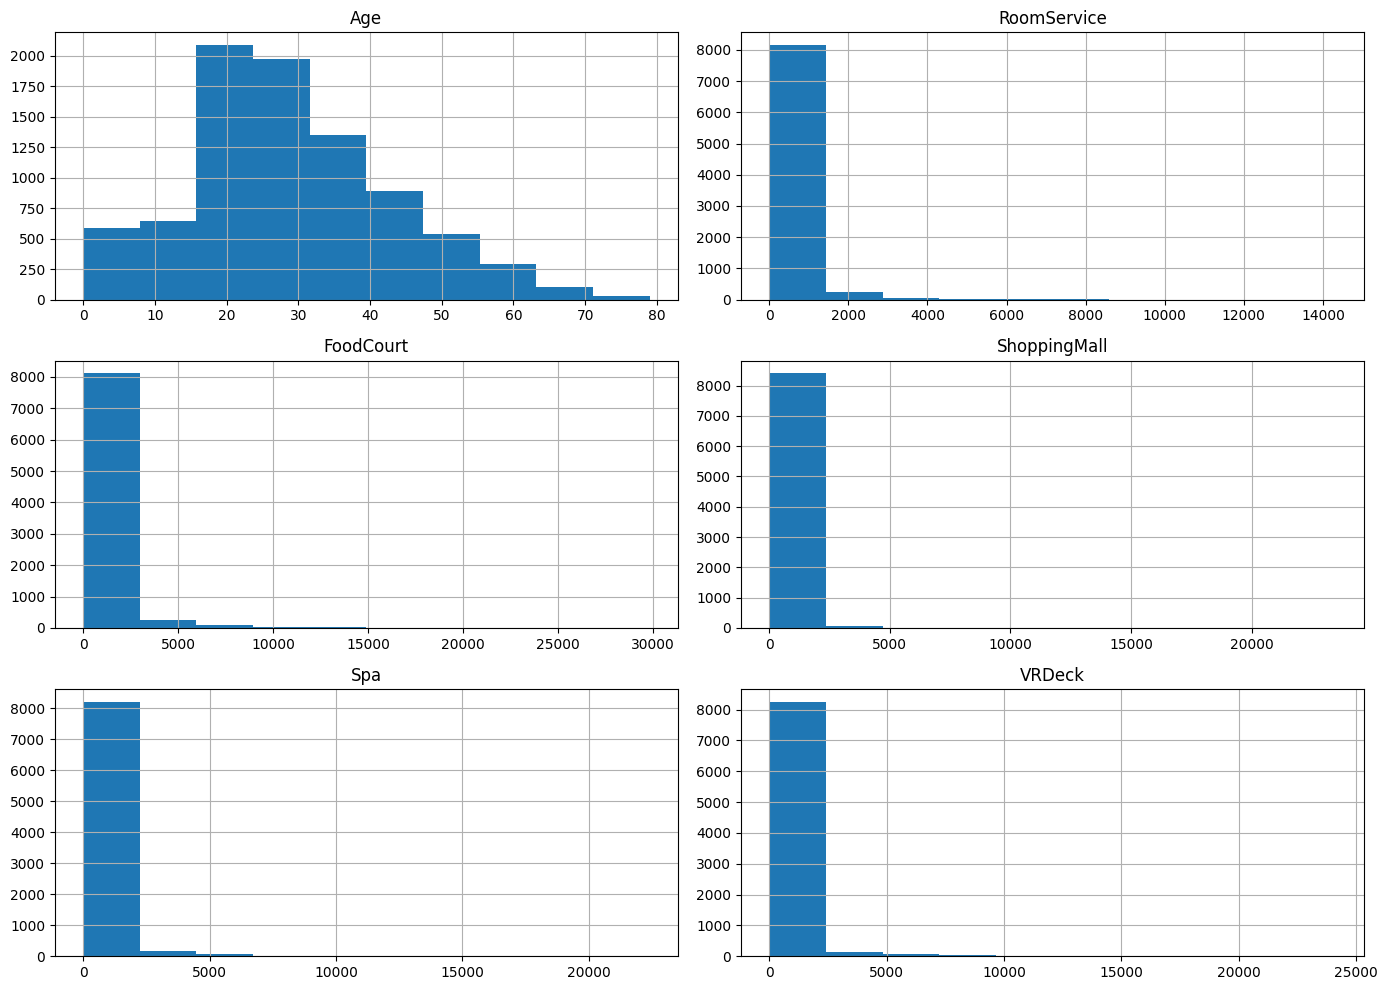

In [7]:
df.hist(figsize=(14, 10))
plt.tight_layout()
plt.show()

# 2. Limpeza de Dados

**Observação do Professor:**
Nesta etapa, primeiro removemos linhas duplicadas. Em seguida:

**Feature Engineering em `Cabin`:** A coluna `Cabin` vem no formato composto `deck/num/side`. Extraímos 3 novas colunas (`Deck`, `Num`, `Side`) e depois descartamos a original. Isso transforma uma string crua em informações estruturizadas que os algoritmos de ML conseguem consumir.

**Imputação de nulos (regra de ouro):**
- **Variáveis Numéricas com outliers** (`Age`, gastos a bordo): usamos a **Mediana**, pois é robusta a valores extremos.
- **Variáveis Categóricas / Booleanas** (`HomePlanet`, `Destination`, `CryoSleep`, `VIP`, `Deck`, `Side`): usamos a **Moda** (valor mais frequente), que é a única medida de tendência central aplicável a textos e categorias.

Colunas sem valor preditivo direto (`PassengerId`, `Name`, `Num`) são removidas.

In [8]:
# Remove duplicatas
df = df.drop_duplicates()

# --- Feature Engineering: extrai Deck, Num e Side da coluna Cabin ---
df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)
df = df.drop(columns=['Cabin'])

# --- Imputação: variáveis numéricas com mediana ---
for col in ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']:
    df[col] = df[col].fillna(df[col].median())

# 'Num' é string extraída do Cabin; convertemos para numérico e imputamos com mediana
df['Num'] = pd.to_numeric(df['Num'], errors='coerce')
df['Num'] = df['Num'].fillna(df['Num'].median())

# --- Imputação: variáveis categóricas/booleanas com moda ---
for col in ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove colunas sem valor preditivo
df = df.drop(columns=['PassengerId', 'Name'])

df.isnull().sum()

HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
Deck            0
Num             0
Side            0
dtype: int64

**Observação do Professor - Por que Moda e Mediana?**

O motivo de usarmos medidas estatísticas diferentes se deve à natureza dos dados (o tipo da variável) de cada coluna.

Em Ciência de Dados, a forma como tratamos os números é diferente da forma como tratamos categorias (textos). Vamos entender cada caso:

**1. HomePlanet, Destination, CryoSleep, VIP, Deck, Side = Variáveis Categóricas / Booleanas**
Essas colunas contêm texto ou valores True/False. Não é possível calcular a média ou mediana de 'Earth' e 'Mars'. Por isso, a **moda** (valor mais frequente) é a única medida aplicável.

- **A lógica:** Ao usar a moda, estamos dizendo: *"Se não sabemos de qual planeta essa pessoa veio, chutamos que ela veio do planeta de onde a maioria embarcou."*

**2. Age e Gastos a bordo (numéricos com outliers) = Mediana**

- **Por que a Mediana e não a Média?** As colunas de gastos (`RoomService`, `Spa`, etc.) têm valores máximos astronômicos que puxam a média para cima, distorcendo a realidade. A mediana, por ser o valor do meio na distribuição ordenada, ignora os extremos e nos dá um retrato mais fiel do gasto típico do passageiro.

💡 **Resumo da Regra de Ouro na imputação de Nulos:**
- **Dados Numéricos (sem muitos outliers):** Média.
- **Dados Numéricos (com outliers ou distorcidos):** Mediana (geralmente a opção mais segura).
- **Dados Categóricos (Textos/Classes) / Booleanos:** Moda.

# 3. Tratamento de Outliers

**Observação do Professor - Tratamento de Outliers (Método IQR):**

Como visualizamos nos histogramas da EDA, as colunas de gastos (`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`) possuem valores absurdamente altos comparados à imensa maioria, criando distribuições com **cauda-longa à direita**.

Para tratá-los matematicamente de forma correta — sem ser por "chute" — nós adotamos o consagrado **Método IQR (Intervalo Interquartil)**, a mesma matemática que rege os famosos gráficos de *Boxplot*.
- Primeiro, descobrimos os valores do **Quartil 1 (25%)** e **Quartil 3 (75%)**.
- A diferença entre eles gera o **IQR (Intervalo)**.
- As "cercas" (bounds/limites aceitáveis) são estipuladas com um limite de `1.5 * IQR` acima e abaixo dos quartis.

Tudo que furar essa cerca consideramos outlier e o removemos do dataset!

![Tratamento de Outliers (IQR)](..//aula-01-titanic/image/outliers.jpg)

In [9]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

for col in spend_cols:
    Q1 = df[col].quantile(0.25)  # calcula o primeiro quartil
    Q3 = df[col].quantile(0.75)  # calcula o terceiro quartil
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR      # margem de tolerância inferior
    upper = Q3 + 1.5 * IQR      # margem de tolerância superior
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(f'Shape após remoção de outliers: {df.shape}')

Shape após remoção de outliers: (3659, 14)


# 4. Transformações Estatísticas

**Observação do Professor:**
Aqui nas transformações, aplicamos a **Transformação Logarítmica** (`np.log1p`) nas colunas de gastos a bordo. Fizemos isso pois variáveis monetárias frequentemente apresentam uma forte assimetria à direita (cauda longa com valores extremos), e essa transformação ajuda a normalizar a distribuição dos dados.

Usamos `log1p` (que calcula `log(1 + x)`) em vez de `log` simples para evitar problemas com valores zero, já que muitos passageiros não gastaram nada em determinados serviços.

**O "Poder Mágico" do Logaritmo:**
A função principal do logaritmo na estatística é ser um **compressor de diferenças grandes**. Ele encurta a distância física entre os números astronômicos, sem alterar a ordem das variáveis (quem for o maior gastador continuará sendo o maior, porém a discrepância quantitativa será "espremida").

Exemplo prático de compressão (base 10 para fins didáticos):

Caso tivéssemos 3 passageiros gastando: 10 ... 100 ... e 1000.

Distância sem usar Log: Entre 10 e 1000 a distância pura num gráfico é enorme! (1000 - 10 = diferença de 990).
A mágica do Log: log10(10) = 1 | log10(100) = 2 | log10(1000) = 3
Conclusão: Após o Log, os exatos mesmos valores se transformam numa nova coluna onde valem: 1 ... 2 ... e 3.
Pronto! Nós pegamos uma série de preços com um pico astronômico e a forçamos a assumir um comportamento mais suave, próximo de uma distribuição de sino. E aí sim o aprendizado de máquina funciona da melhor forma!

In [10]:
for col in spend_cols:
    df[f'{col}_log'] = np.log1p(df[col])

# Remove as colunas originais de gastos (substituídas pelas versões log)
df = df.drop(columns=spend_cols)

**Observação do Professor:**

Logo após, com o auxílio do `StandardScaler`, padronizamos as features contínuas numéricas. Colocá-las na mesma escala (com média 0 e desvio padrão 1) é fundamental para garantir a performance e a convergência de muitos algoritmos de Machine Learning que são sensíveis à escala dos dados.

In [11]:
numeric_features = ['Age', 'Num'] + [f'{col}_log' for col in spend_cols]

scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

# 5. Encoding

**Observação do Professor:**
Nesta célula, realizamos o **Encoding** das variáveis categóricas e booleanas para que os algoritmos de Machine Learning consigam processá-las.

- **One-Hot Encoding** (`pd.get_dummies`): Aplicado às variáveis nominais `HomePlanet`, `Destination`, `Deck` e `Side`. Cada categoria vira uma coluna binária (0 ou 1). Usamos `drop_first=True` para evitar a **armadilha da variável dummy** (multicolinearidade perfeita), que prejudica especialmente modelos lineares.
- **Conversão Booleana**: `CryoSleep` e `VIP` são booleanos (`True`/`False`). Mapeamos para `1`/`0` diretamente, pois já possuem apenas dois estados.
- **Target**: `Transported` também é booleano e é convertido para `1`/`0`.

In [12]:
# One-Hot Encoding para variáveis nominais
df = pd.get_dummies(df, columns=['HomePlanet', 'Destination', 'Deck', 'Side'], drop_first=True)

# Conversão de booleanos para 0/1
for col in ['CryoSleep', 'VIP', 'Transported']:
    df[col] = df[col].map({True: 1, False: 0}).astype(int)

df.head()

,CryoSleep,Age,VIP,Transported,Num,RoomService_log,FoodCourt_log,ShoppingMall_log,Spa_log,VRDeck_log,...,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Side_S
0,0,0.890492,0,0,-1.202898,-0.031294,-0.025376,0.0,0.0,0.0,...,False,False,True,True,False,False,False,False,False,False
7,1,0.192890,0,1,-1.202898,-0.031294,-0.025376,0.0,0.0,0.0,...,False,False,True,False,False,False,False,False,True,True
9,1,-0.694968,0,1,-1.200809,-0.031294,-0.025376,0.0,0.0,0.0,...,False,False,False,True,False,False,False,False,False,False
10,1,0.573400,0,1,-1.200809,-0.031294,-0.025376,0.0,0.0,0.0,...,False,False,True,True,False,False,False,False,False,False
18,1,1.271003,0,1,-1.192455,-0.031294,-0.025376,0.0,0.0,0.0,...,True,False,True,False,False,False,False,True,False,False


# 6. Seleção de Features

**Observação do Professor:**
Atenção para um detalhe metodológico muito importante! O uso da função `chi2` (Qui-Quadrado) para a seleção de atributos **exige que os dados de entrada sejam restritamente não-negativos**. Como padronizamos os dados com o `StandardScaler` na etapa anterior, valores negativos foram introduzidos em nosso conjunto.

Por isso, utilizamos a métrica **`f_classif` (Análise de Variância — ANOVA F-test)**, que lida corretamente com variáveis contínuas padronizadas (incluindo valores negativos) em problemas de classificação. A `f_classif` mede o quão bem cada feature separa estatisticamente as classes do nosso target (`Transported`: 0 ou 1).

In [13]:
X = df.drop(columns=['Transported'])
y = df['Transported']

In [14]:
selector = SelectKBest(score_func=f_classif, k=8)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print('Features selecionadas:')
selected_features

Features selecionadas:


/home/saulo/cursos/engenharia-dados/titanic/aula-02-exe-titanic-sci/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [6 7 8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/saulo/cursos/engenharia-dados/titanic/aula-02-exe-titanic-sci/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Index(['CryoSleep', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Deck_B', 'Deck_C',
       'Deck_E', 'Deck_F', 'Deck_G'],
      dtype='str')

# 7. Split do Dataset

**Observação do Professor - Prevenção ao Vazamento de Dados (Data Leakage):**

Chegamos à separação do dataset! Faço este alerta agora para ressaltar a seguinte escolha que inseri neste material didático: realizamos imputações (mediana/moda), tratamento de outliers e padronização ANTES de invocar o `train_test_split`.

Atenção redobrada na prática: os dados de teste sempre representam eventos futuros. Se eu calcular uma métrica global para imputação agrupando o dataset inteiro, estarei vazando informações do teste para o treino do modelo, tornando-o ingenuamente otimista. Em desafios mais avançados em nosso curso, aplicaremos os `Pipelines` do `scikit-learn` para blindar completamente o modelo desses riscos!

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X[selected_features], y, test_size=0.2, random_state=42
)

print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')

Treino: (2927, 8) | Teste: (732, 8)


# Balanceamento com SMOTE

**Observação do Professor:**

O dataset Spaceship Titanic é relativamente balanceado (~50% transportados vs ~50% não transportados), mas aplicamos o SMOTE como prática do pipeline completo. Em datasets mais desbalanceados (como o Churn Modelling), o SMOTE é essencial para evitar que o modelo aprenda a prever apenas a classe majoritária.

In [16]:
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f'Antes do SMOTE:  {X_train.shape}')
print(f'Após o SMOTE:    {X_train_balanced.shape}')
print(f'Distribuição após SMOTE:\n{pd.Series(y_train_balanced).value_counts()}')

Antes do SMOTE:  (2927, 8)
Após o SMOTE:    (4608, 8)
Distribuição após SMOTE:
Transported
1    2304
0    2304
Name: count, dtype: int64
